# EDA for raw dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/bank.csv")

In [3]:
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


---
## 1 Data Understanding

- Loading the dataset, inspecting data types, number of unique values, and descriptive statistics
- Verifying whether the data meets expectations: column data types, category distributions, and potential data issues

In [4]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 2.0 MB


None

In [5]:
print('Liczba unikalnych wartości w kolumnach:')
print(df.nunique())

Liczba unikalnych wartości w kolumnach:
age            76
job            12
marital         3
education       4
default         2
balance      3805
housing         2
loan            2
contact         3
day            31
month          12
duration     1428
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64


In [6]:
display(df.describe(include='all'))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,11162.000000,11162,11162,11162,11162,11162.000000,11162,11162,11162,11162.000000,11162,11162.000000,11162.000000,11162.000000,11162.000000,11162,11162
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,2566,6351,5476,10994,NaN,5881,9702,8042,NaN,2824,NaN,NaN,NaN,NaN,8326,5873
mean,41.231948,NaN,NaN,NaN,NaN,1528.538524,NaN,NaN,NaN,15.658036,NaN,371.993818,2.508421,51.330407,0.832557,NaN,NaN
std,11.913369,NaN,NaN,NaN,NaN,3225.413326,NaN,NaN,NaN,8.420740,NaN,347.128386,2.722077,108.758282,2.292007,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,122.000000,NaN,NaN,NaN,8.000000,NaN,138.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,550.000000,NaN,NaN,NaN,15.000000,NaN,255.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1708.000000,NaN,NaN,NaN,22.000000,NaN,496.000000,3.000000,20.750000,1.000000,NaN,NaN


## 2. Data Cleaning

* Removing unnecessary or irrelevant columns
* Checking for and removing duplicate records
* Analyzing missing data and handling null values
* Fixing typos and inconsistencies in categorical data
* Verifying and correcting data types for each column
* Identifying potential data quality issues and anomalies

In [7]:
print('Duplikaty:', df.duplicated().sum())

Duplikaty: 0


In [8]:
missing = pd.DataFrame({'count': df.isnull().sum(), 'percent': df.isnull().mean()*100})
print('Brakujące wartości:')
print(missing[missing['count'] > 0])

Brakujące wartości:
Empty DataFrame
Columns: [count, percent]
Index: []


## 3. Analysis & Visualization

 - Distribution analysis of numerical variables (histograms) and categorical variables (value counts), along with outlier detection
- Analysis of distributions, potential outliers, and class imbalance

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from IPython.display import display

import math

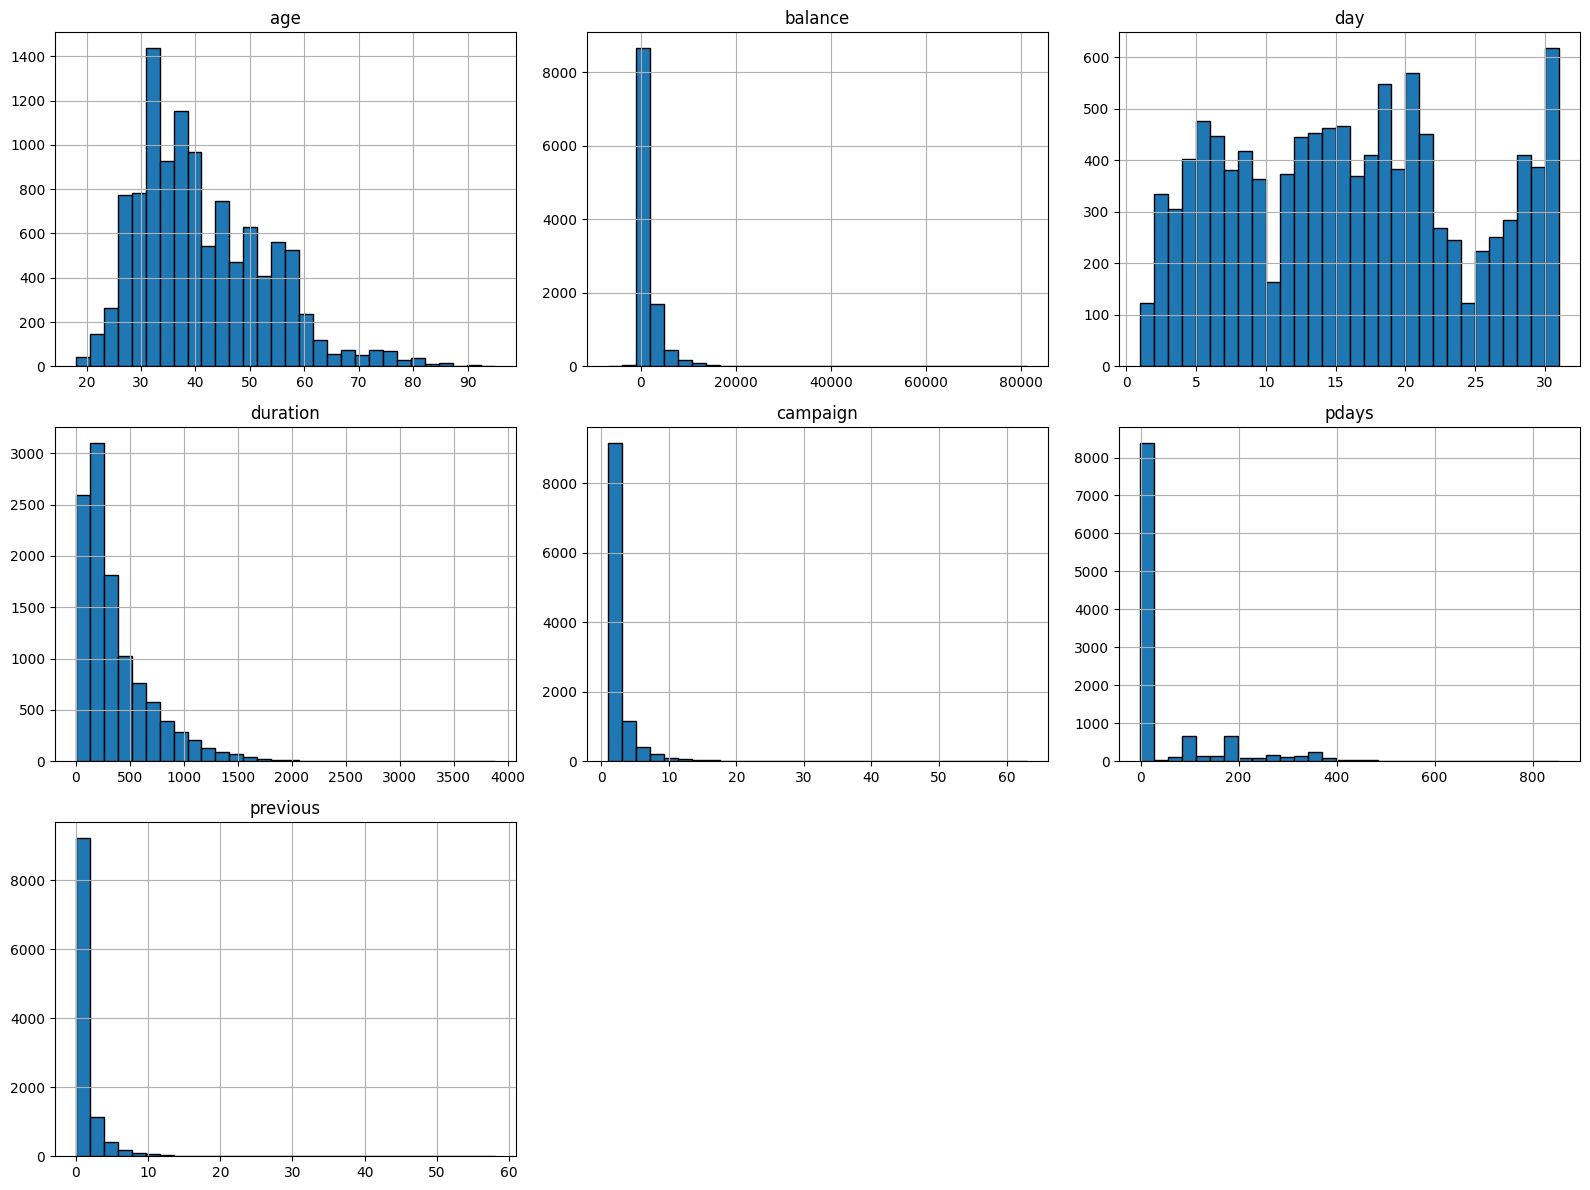

In [10]:
df.hist(figsize=(16, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

In [11]:
tabs = []

for col in df.select_dtypes(include='object').columns:
    out = widgets.Output()
    with out:
        display(df[col].value_counts())
    tabs.append(out)

tab = widgets.Tab(children=tabs)

for i, col in enumerate(df.select_dtypes(include='object').columns):
    tab.set_title(i, col)

display(tab)

C:\Users\user\AppData\Local\Temp\ipykernel_10772\2497980291.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


C:\Users\user\AppData\Local\Temp\ipykernel_10772\2497980291.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i, col in enumerate(df.select_dtypes(include='object').columns):


C:\Users\user\AppData\Local\Temp\ipykernel_10772\1378394433.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = df.select_dtypes(include='object').columns


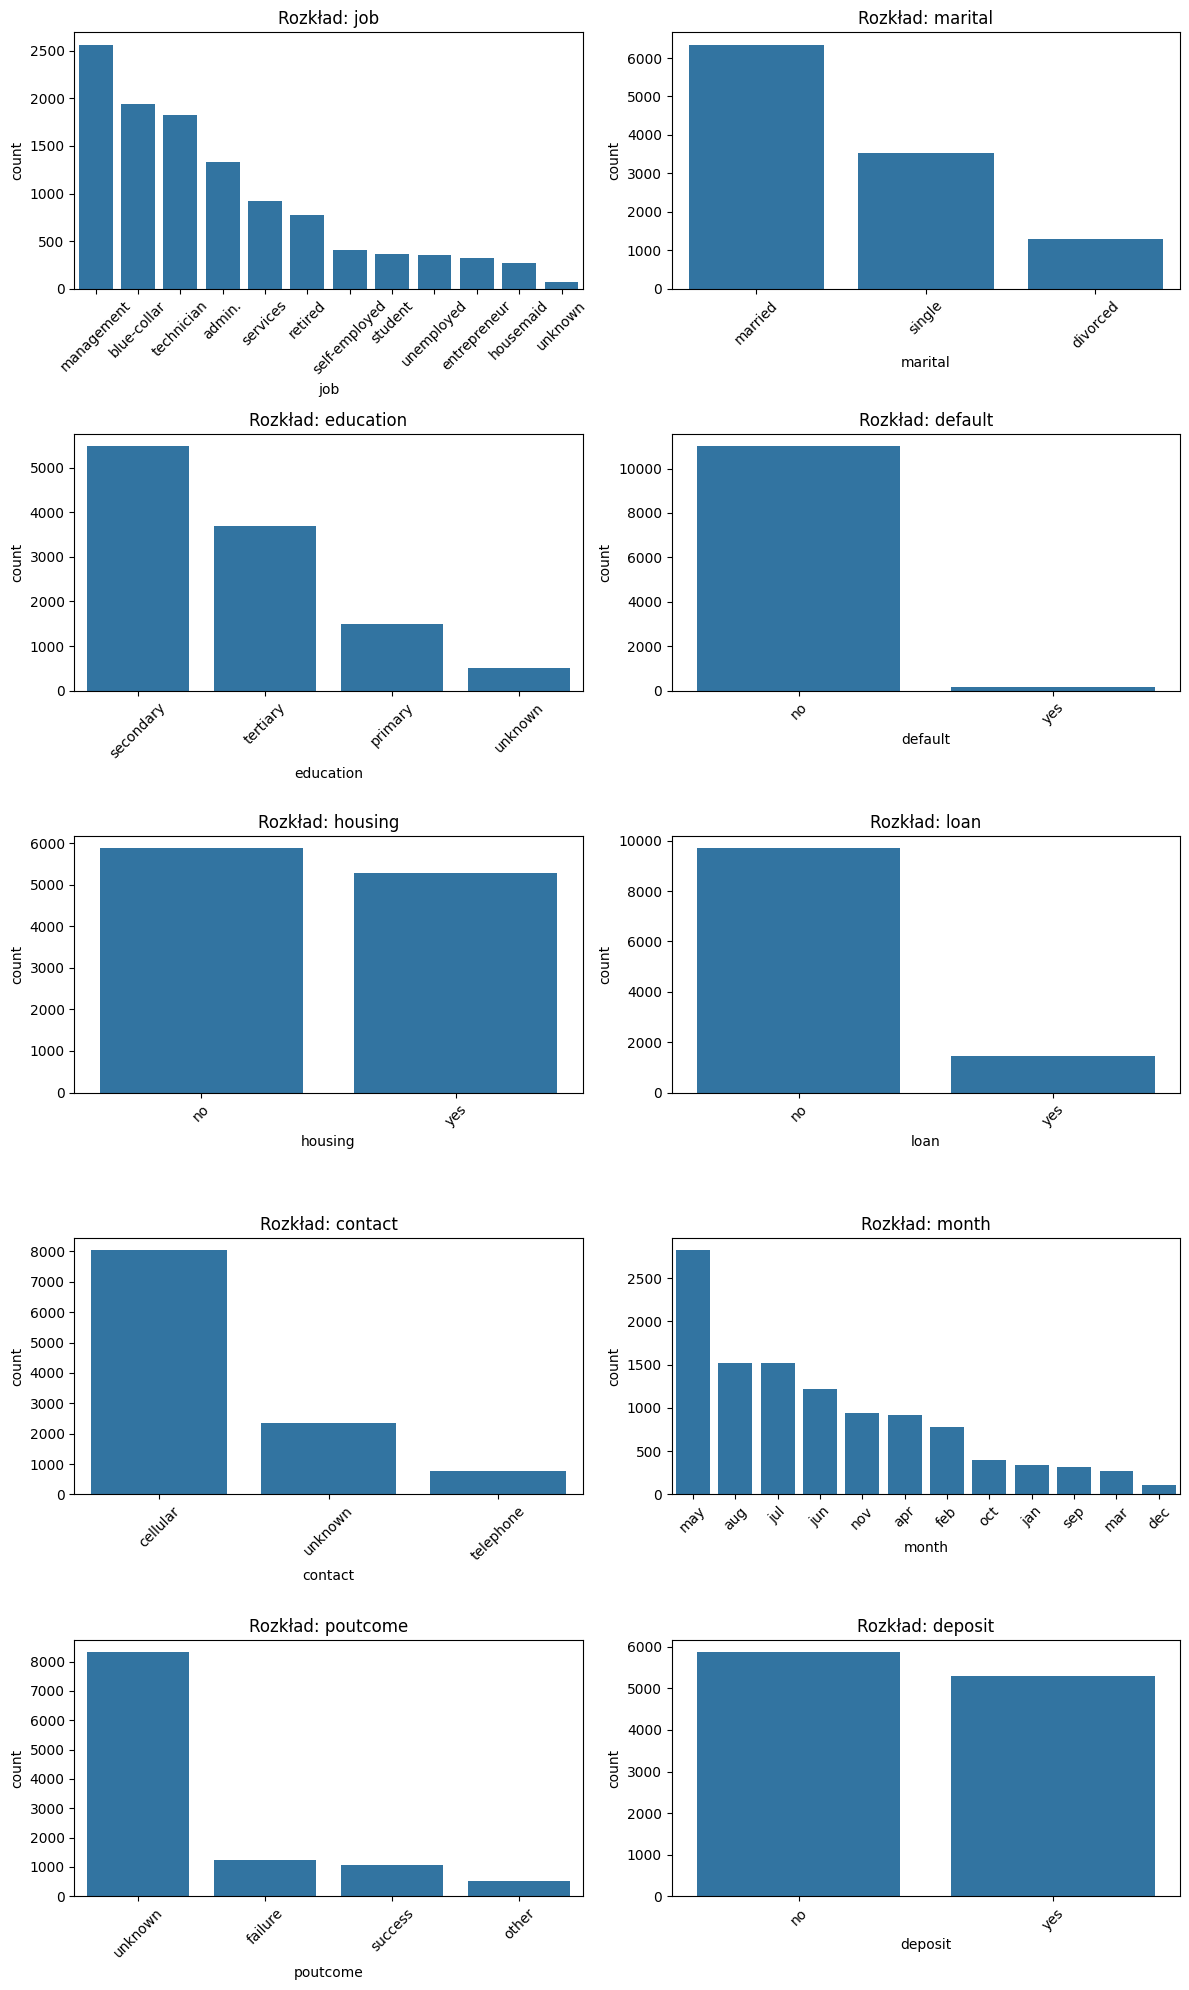

In [12]:
cols = df.select_dtypes(include='object').columns
n = len(cols)

n_cols = 2  # ile wykresów w rzędzie
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(cols):
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        ax=axes[i]
    )
    axes[i].set_title(f'Rozkład: {col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
print('Rozkłady zmiennych kategorycznych:')

tabs = []

for col in df.select_dtypes(include='object').columns:
    out = widgets.Output()
    with out:
        display(df[col].value_counts(normalize=True).round(3))
    tabs.append(out)

tab = widgets.Tab(children=tabs)

for i, col in enumerate(df.select_dtypes(include='object').columns):
    tab.set_title(i, col)

display(tab)

Rozkłady zmiennych kategorycznych:


C:\Users\user\AppData\Local\Temp\ipykernel_10772\2084399669.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


C:\Users\user\AppData\Local\Temp\ipykernel_10772\2084399669.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i, col in enumerate(df.select_dtypes(include='object').columns):


## 4. Conclusions

Podsumowanie jakości danych, rozkładów, korelacji, rekomendacje dalszych kroków


In [14]:
print('Podsumowanie jakości danych:')
print('Duplikaty:', df.duplicated().sum())
print('Brakujące wartości:')
print(missing[missing['count'] > 0])

Podsumowanie jakości danych:
Duplikaty: 0
Brakujące wartości:
Empty DataFrame
Columns: [count, percent]
Index: []


---

### Jakość danych

- **Brak duplikatów:** Zbiór nie zawiera powielonych wierszy.
- **Brak brakujących wartości:** Wszystkie kolumny są kompletne.
- **Typy danych:** Kolumny mają odpowiednie typy (`int64` dla numerycznych, `str` dla kategorycznych).

---

### Rozkłady zmiennych kategorycznych

- **job:** Najwięcej klientów to management, blue-collar, technician, admin. Bardzo mało "unknown" (0.6%).
- **marital:** Przeważają osoby zamężne/żonate (57%), potem single (31%), rozwiedzeni (11%).
- **education:** Dominują osoby z wykształceniem secondary (49%) i tertiary (33%). "unknown" to tylko 4.5%.
- **default:** Zdecydowana większość nie ma zaległości kredytowych (98.5% "no").
- **housing:** Prawie pół na pół z kredytem hipotecznym (47%) i bez (53%).
- **loan:** Większość nie ma pożyczki (87% "no").
- **contact:** Najczęściej kontakt przez cellular (72%), rzadziej unknown (21%) i telephone (7%).
- **month:** Najwięcej kontaktów w maju (25%), potem sierpień, lipiec, czerwiec.
- **poutcome:** 75% "unknown" (brak wcześniejszej kampanii), 11% "failure", 10% "success".
- **deposit (target):** Klasy są dość zbalansowane (53% "no", 47% "yes").

---

### Wnioski i rekomendacje

- **Brak braków i duplikatów** — dane są czyste, nie wymagają imputacji ani deduplikacji.
- **Niezbalansowanie klas:** Zmienna docelowa (`deposit`) jest dobrze zbalansowana, co jest korzystne dla modelowania.
- **Dominujące kategorie:** W niektórych zmiennych (np. `default`, `loan`) jedna wartość dominuje — mogą mieć ograniczoną moc predykcyjną.
- **Wysoki udział "unknown":** W `poutcome` i częściowo w `education` — warto rozważyć, czy traktować "unknown" jako osobną kategorię, czy próbować imputować.
- **Brak outlierów i błędów typów** na tym etapie — histogramy i statystyki opisowe nie wykazały problemów (jeśli coś wzbudzi wątpliwości, sprawdź konkretne kolumny).

---
## 5. Analiza numeryczna i korelacje
W tej sekcji sprawdzimy rozkłady zmiennych numerycznych (`age`, `balance`, `duration`, `campaign`, `pdays`, `previous`, `day`) pod kątem skośności i outlierów oraz zbadamy korelacje tych cech z celem (`deposit`).

### a) Histogramy i boxploty dla zmiennych numerycznych

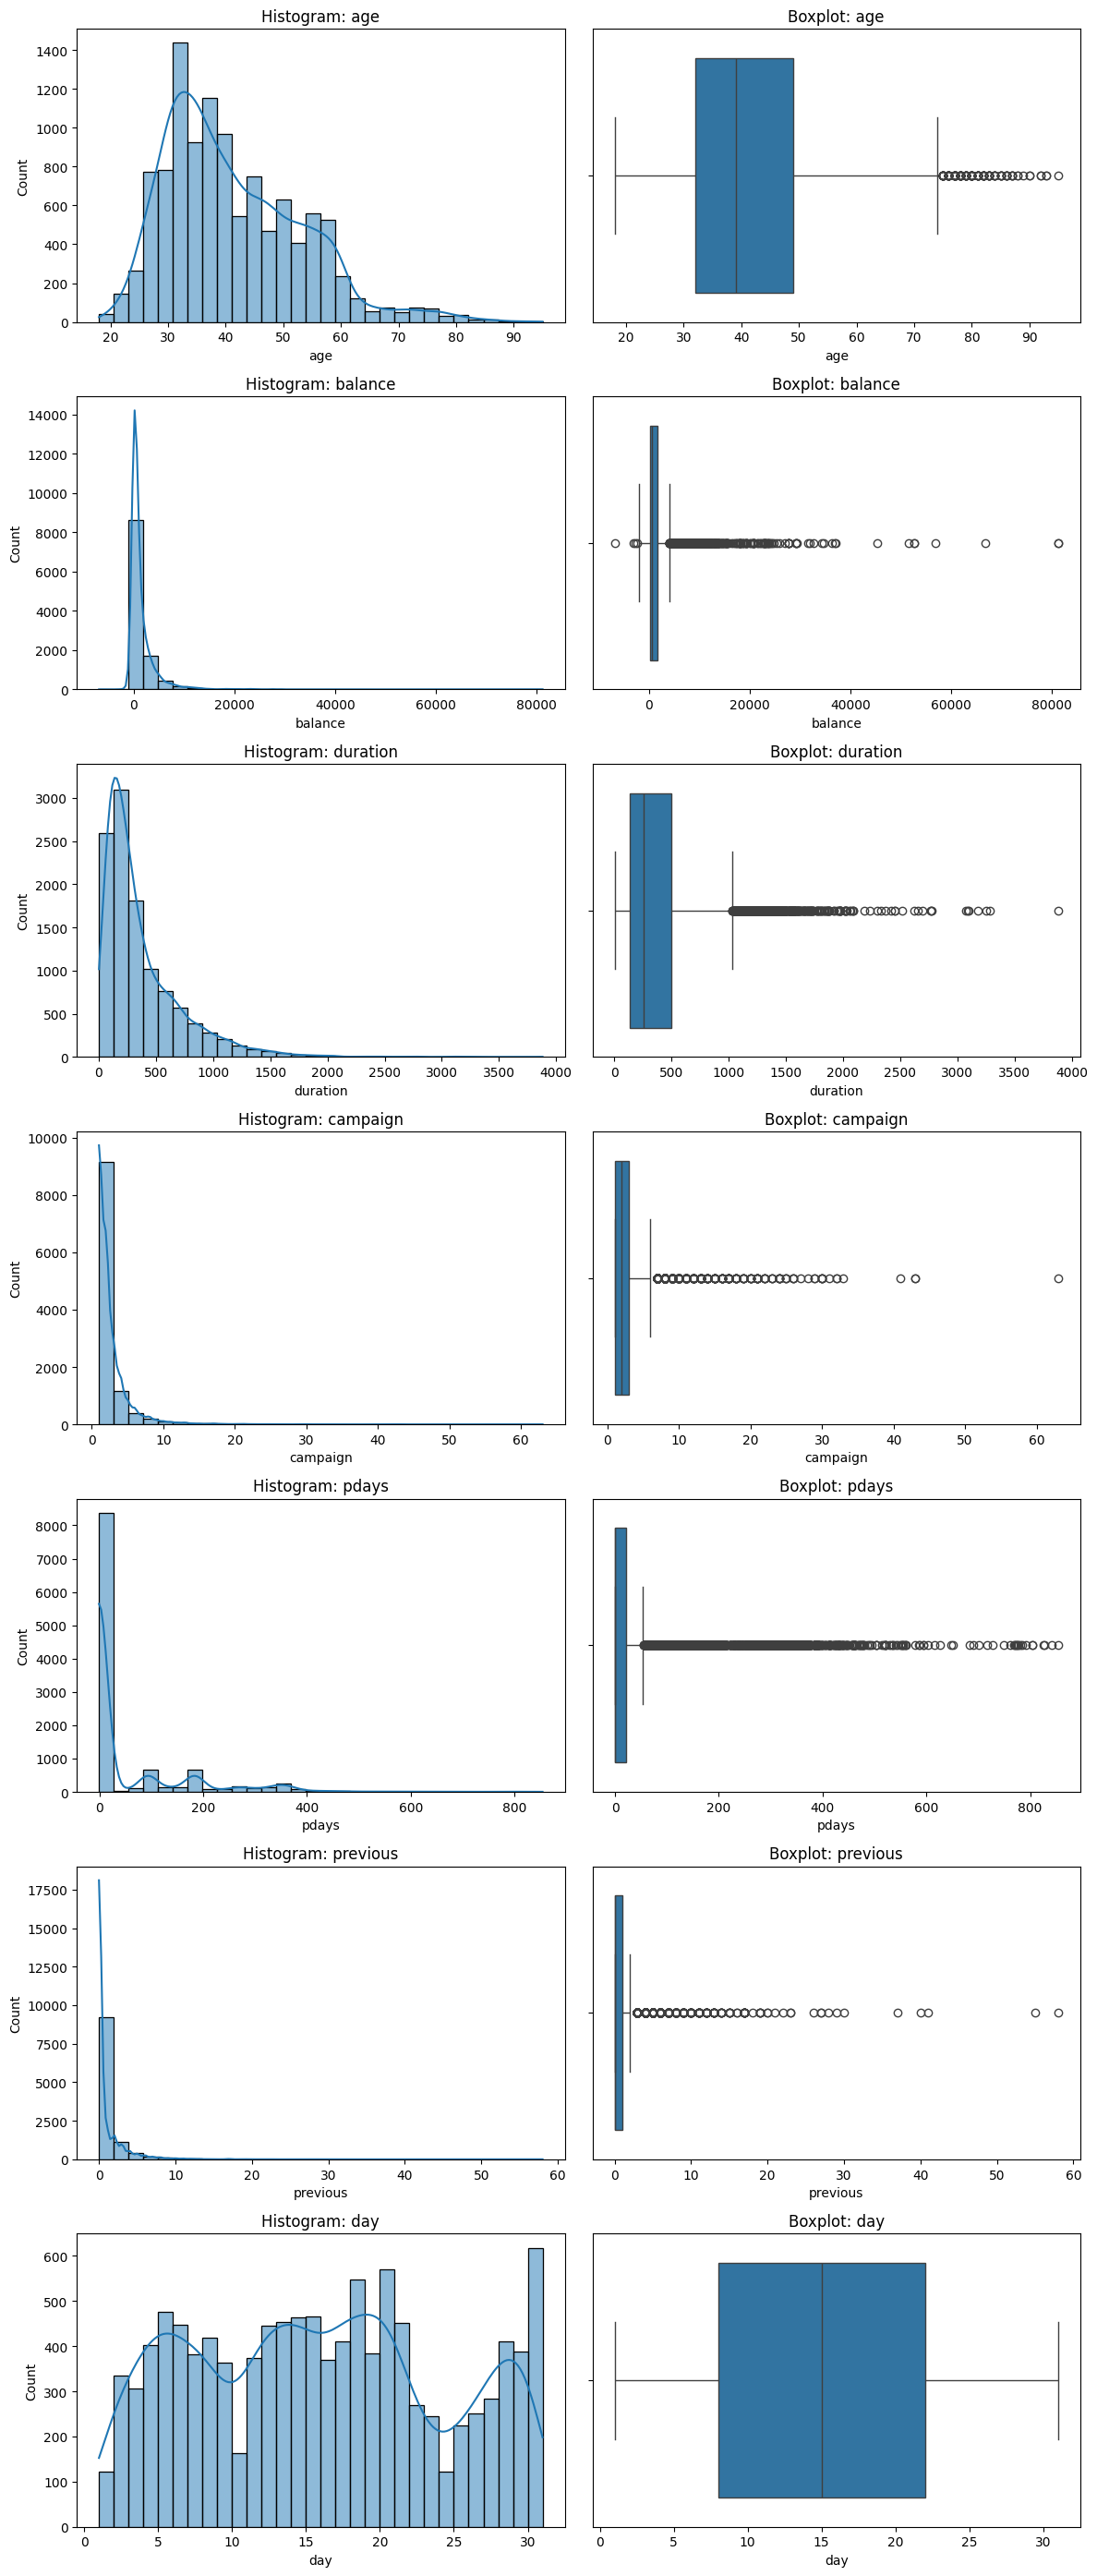

In [15]:

num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4*len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i,0])
    axes[i,0].set_title(f'Histogram: {col}')
    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


- Rozkłady i boxploty pokazują, że większość zmiennych numerycznych jest silnie skośna (balance, duration, campaign, pdays, previous).
- Outliery są obecne w balance, duration, campaign, previous.
- day jest równomiernie rozłożone, age lekko skośne.

### b) Statystyki opisowe i skośność


In [16]:
desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
display(desc)

,count,mean,std,min,25%,50%,75%,max,skew
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0,0.862780
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0,8.224619
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0,2.143695
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0,5.545578
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0,2.449986
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0,7.335298
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0,0.111330


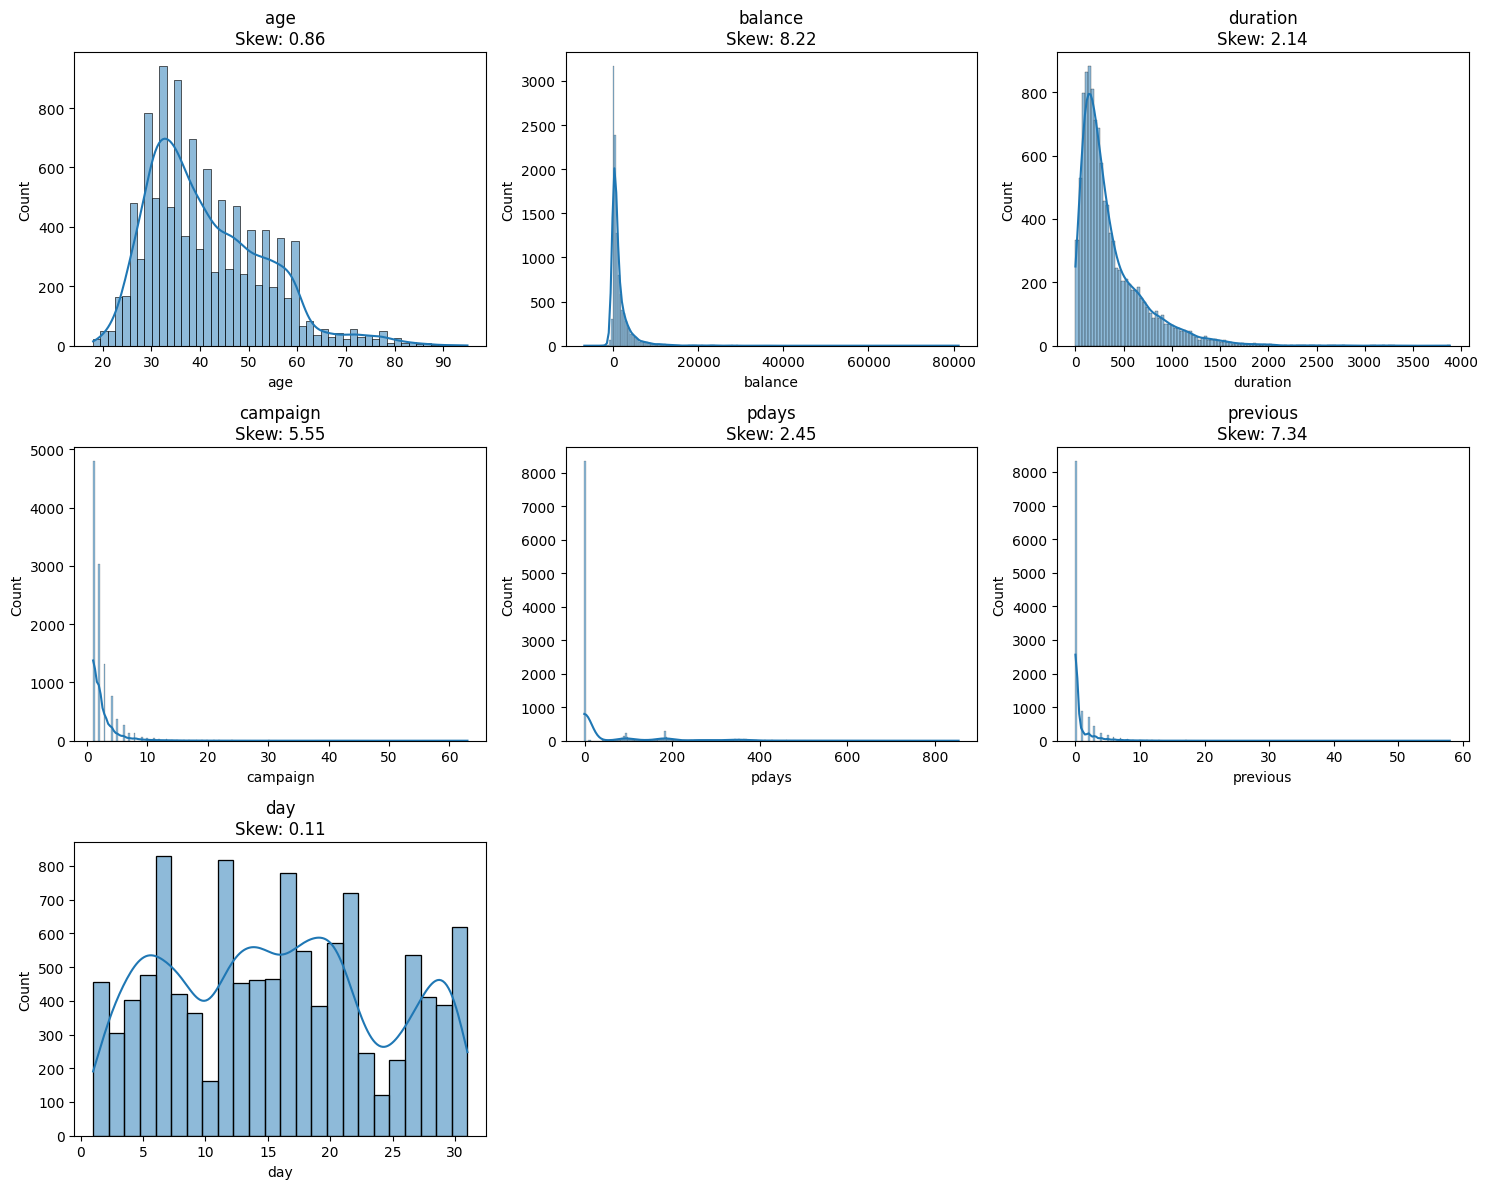

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = num_cols
n = len(cols)

n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col}\nSkew: {df[col].skew():.2f}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Wnioski: Rozkłady i skośność

- **age**: Rozkład zbliżony do normalnego, lekko prawostronnie skośny. Brak wyraźnych outlierów.
- **balance**: Silnie skośny w prawo, obecne outliery (pojedyncze bardzo wysokie wartości). Większość klientów ma niskie saldo, ale są ekstremalne przypadki.
- **duration**: Również silnie skośny w prawo, dużo krótkich rozmów, pojedyncze bardzo długie (outliery).
- **campaign**: Większość klientów miała 1–2 kontakty, ale są przypadki z kilkunastoma kontaktami (outliery).
- **pdays**: Dużo wartości -1 (brak wcześniejszego kontaktu), reszta rozkładu rozciągnięta.
- **previous**: Większość to 0, pojedyncze przypadki z kilkunastoma kontaktami.
- **day**: Rozkład równomierny (dni miesiąca).


In [18]:
# Korelacje cech numerycznych z celem (deposit)
# Zamiana celu na 0/1
df['deposit_bin'] = (df['deposit'] == 'yes').astype(int)
corrs = df[num_cols + ['deposit_bin']].corr(method='pearson')['deposit_bin'].drop('deposit_bin')
print('Korelacje Pearsona z celem (deposit):')
print(corrs.sort_values(key=abs, ascending=False))

Korelacje Pearsona z celem (deposit):
duration    0.451919
pdays       0.151593
previous    0.139867
campaign   -0.128081
balance     0.081129
day        -0.056326
age         0.034901
Name: deposit_bin, dtype: float64


In [19]:
# Korelacje Spearmana (dla niesymetrycznych/skosnych)
corrs_spearman = df[num_cols + ['deposit_bin']].corr(method='spearman')['deposit_bin'].drop('deposit_bin')
print('Korelacje Spearmana z celem (deposit):')
print(corrs_spearman.sort_values(key=abs, ascending=False))

Korelacje Spearmana z celem (deposit):
duration    0.527801
previous    0.229905
pdays       0.212805
balance     0.157584
campaign   -0.126666
day        -0.058325
age        -0.012156
Name: deposit_bin, dtype: float64


### Wnioski - Korelacje z celem (`deposit`)

- **duration**: Najsilniejsza korelacja z celem (Pearson: 0.45, Spearman: 0.53). Im dłuższa rozmowa, tym większa szansa na depozyt. **UWAGA:** duration to zmienna post-treatment (Może być użyteczny tylko do analizy skuteczności kampanii, nie do predykcji zachowań klientów.).
- **pdays, previous**: Umiarkowana dodatnia korelacja (0.14–0.23). Im więcej wcześniejszych kontaktów, tym większa szansa na depozyt.
- **campaign**: Słaba, ujemna korelacja (~-0.13). Więcej kontaktów w bieżącej kampanii nieznacznie zmniejsza szansę na sukces.
- **balance**: Bardzo słaba dodatnia korelacja (0.08–0.16).
- **day, age**: Praktycznie brak korelacji.


## 6. Wnioski

- **duration** jest silnie powiązane z celem, ale nie wolno jej używać do modelowania przyczynowego (post-treatment bias).
- **pdays** - 
    - Warto rozdzielić na dwie cechy: 

        (a) czy był wcześniejszy kontakt (pdays != -1) 

        (b) liczba dni od kontaktu (dla pdays > -1).

    - wartość -1 oznacza brak wcześniejszego kontaktu i powinna być traktowana jako osobna kategoria 
    - **Silna skośność** — rozważyć binaryzację i/lub transformację.

- **previous**:
    - Umiarkowana dodatnia korelacja (0.14–0.23). Im więcej wcześniejszych kontaktów, tym większa szansa na depozyt.

    - Silnie skośna - większość klientów nie miała wcześniejszych kontaktów. Rozważyć log-transformację (np. log1p)
    
    - `transformacje logarytmiczne` wymagają przesunięcia wartości, jeśli występują zera lub wartości ujemne.

- **balance** - Silnie skośna, obecne outliery. Rozważyć log1p(balance - min(balance) + 1) lub winsoryzację.
    - `transformacje logarytmiczne` wymagają przesunięcia wartości, jeśli występują zera lub wartości ujemne.

- **campaign** - Słaba, ujemna korelacja z celem. Outliery mogą zaburzać model — rozważyć ograniczenie wartości maksymalnych.

- **age** i **day** nie mają znaczenia predykcyjnego.
    - age może być istotne w interakcji z innymi cechami (np. segmentacja klientów).

- Warto rozważyć usunięcie outlierów z `balance`, `duration`, `campaign`, `previous` lub ich transformację.

- zmienne kategoryczne z dużym udziałem "unknown" (np. poutcome, education) wymagają przemyślenia strategii kodowania.

- Warto podkreślić, że campaign i previous mogą być powiązane z intensywnością kampanii, a nie tylko cechami klienta.